In [ ]:
import pandas as pd
import os

folder_path = "/content/drive/MyDrive/Dataset"

files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

print("Files found:", files)

df = pd.concat([pd.read_csv(os.path.join(folder_path, f)) for f in files])

print("Shape:", df.shape)
df.head()

Files found: ['1.csv', '2.csv', '3.csv', '4.csv', '5.csv', '6.csv', '7.csv', '8.csv', '9.csv', '10.csv', '11.csv']
Shape: (37350, 15)


,location_id,location_name,parameter,value,unit,datetimeUtc,datetimeLocal,timezone,latitude,longitude,country_iso,isMobile,isMonitor,owner_name,provider
0,5630,"Shadipur, Delhi - CPCB",co,0.019,ppb,2026-03-01T00:15:00Z,2026-03-01T05:45:00+05:30,Asia/Kolkata,28.651478,77.147311,NaN,NaN,NaN,Central Pollution Control Board,CPCB
1,5630,"Shadipur, Delhi - CPCB",co,0.152,ppb,2026-03-01T00:30:00Z,2026-03-01T06:00:00+05:30,Asia/Kolkata,28.651478,77.147311,NaN,NaN,NaN,Central Pollution Control Board,CPCB
2,5630,"Shadipur, Delhi - CPCB",co,0.160,ppb,2026-03-01T00:45:00Z,2026-03-01T06:15:00+05:30,Asia/Kolkata,28.651478,77.147311,NaN,NaN,NaN,Central Pollution Control Board,CPCB
3,5630,"Shadipur, Delhi - CPCB",co,0.121,ppb,2026-03-01T01:00:00Z,2026-03-01T06:30:00+05:30,Asia/Kolkata,28.651478,77.147311,NaN,NaN,NaN,Central Pollution Control Board,CPCB
4,5630,"Shadipur, Delhi - CPCB",co,0.095,ppb,2026-03-01T01:15:00Z,2026-03-01T06:45:00+05:30,Asia/Kolkata,28.651478,77.147311,NaN,NaN,NaN,Central Pollution Control Board,CPCB


In [ ]:
df_wide = df.pivot_table(
    index='datetimeUtc',
    columns='parameter',
    values='value'
).reset_index()

print(df_wide.shape)
df_wide.head()

(4681, 9)


parameter,datetimeUtc,co,no,no2,o3,pm10,relativehumidity,temperature,wind_speed
0,2026-01-01T00:15:00Z,1.189,7.32,30.38,39.00,275.3,15.52,10.83,0.82
1,2026-01-01T00:30:00Z,1.171,5.54,30.97,34.75,275.3,15.52,10.83,0.75
2,2026-01-01T00:45:00Z,1.187,7.75,31.67,21.88,275.3,15.52,10.87,0.81
3,2026-01-01T01:00:00Z,1.168,6.92,29.28,0.00,277.6,15.52,10.91,0.71
4,2026-01-01T01:15:00Z,1.102,5.45,27.84,27.86,277.6,15.52,10.93,0.59


In [ ]:
df_wide.to_csv("/content/final_clean_data.csv", index=False)

In [ ]:
import pandas as pd

df = pd.read_csv("/content/final_clean_data.csv")

# convert datetime
df['datetime'] = pd.to_datetime(df['datetimeUtc'])

# sort by time
df = df.sort_values('datetime')

# drop old column
df = df.drop(columns=['datetimeUtc'])

# forward fill missing values
df = df.fillna(method='ffill')

# drop any remaining nulls
df = df.dropna()

print(df.shape)
df.head()

(4681, 9)


/tmp/ipykernel_3850/3276810181.py:15: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


,co,no,no2,o3,pm10,relativehumidity,temperature,wind_speed,datetime
0,1.189,7.32,30.38,39.00,275.3,15.52,10.83,0.82,2026-01-01 00:15:00+00:00
1,1.171,5.54,30.97,34.75,275.3,15.52,10.83,0.75,2026-01-01 00:30:00+00:00
2,1.187,7.75,31.67,21.88,275.3,15.52,10.87,0.81,2026-01-01 00:45:00+00:00
3,1.168,6.92,29.28,0.00,277.6,15.52,10.91,0.71,2026-01-01 01:00:00+00:00
4,1.102,5.45,27.84,27.86,277.6,15.52,10.93,0.59,2026-01-01 01:15:00+00:00


In [ ]:
df['nox'] = df['no'] + df['no2']

df[['no', 'no2', 'nox']].head()

,no,no2,nox
0,7.32,30.38,37.70
1,5.54,30.97,36.51
2,7.75,31.67,39.42
3,6.92,29.28,36.20
4,5.45,27.84,33.29


In [ ]:
df['hour'] = df['datetime'].dt.hour

df['traffic'] = df['hour'].apply(
    lambda x: 1.5 if 8 <= x <= 11 or 17 <= x <= 20 else 0.5
)

In [ ]:
df['airflow'] = df['wind_speed'] * 0.3

In [ ]:
df['depth'] = 20

In [ ]:
df[['traffic', 'airflow', 'depth']].head()

,traffic,airflow,depth
0,0.5,0.246,20
1,0.5,0.225,20
2,0.5,0.243,20
3,0.5,0.213,20
4,0.5,0.177,20


In [ ]:
import numpy as np

a = 0.6   # traffic impact
b = 1.2   # airflow impact
c = 0.05  # depth impact

df['nox_tunnel'] = (
    df['nox']
    * (1 + a * (df['traffic'] ** 1.2))
    * np.exp(-b * df['airflow'])
    * (1 + c * (df['depth'] ** 0.5))
)

df[['nox', 'traffic', 'airflow', 'depth', 'nox_tunnel']].head()

,nox,traffic,airflow,depth,nox_tunnel
0,37.70,0.5,0.246,20,43.306339
1,36.51,0.5,0.225,20,43.009676
2,39.42,0.5,0.243,20,45.445428
3,36.20,0.5,0.213,20,43.263012
4,33.29,0.5,0.177,20,41.541626


#MODEL TRAINING


In [ ]:
features = [
    'co','no','no2','o3','pm10',
    'relativehumidity','temperature','wind_speed',
    'traffic','airflow','depth'
]

X = df[features]
y = df['nox_tunnel']

print(X.shape, y.shape)

(4681, 11) (4681,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(3744, 11) (937, 11)


#LINEAR MODEL

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

pred_lr = model_lr.predict(X_test)

print("Linear Regression")
print("R2:", r2_score(y_test, pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_lr)))

Linear Regression
R2: 0.9579027108114457
RMSE: 14.934867270455847


#POLYNOMIAL MODEL

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

pred_poly = model_poly.predict(X_test_poly)

print("Polynomial Regression")
print("R2:", r2_score(y_test, pred_poly))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_poly)))

Polynomial Regression
R2: 0.9998427521006075
RMSE: 0.9127812874047039


#RANDOM FOREST

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)

pred_rf = model_rf.predict(X_test)

print("Random Forest")
print("R2:", r2_score(y_test, pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_rf)))

Random Forest
R2: 0.9885165397556546
RMSE: 7.800288891081786


#XGBOOST

In [ ]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5)
model_xgb.fit(X_train, y_train)

pred_xgb = model_xgb.predict(X_test)

print("XGBoost")
print("R2:", r2_score(y_test, pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_xgb)))

XGBoost
R2: 0.98708428159092
RMSE: 8.272439236586743


#SHAP VISUALIZATION

 99%|===================| 928/937 [01:09<00:00]       

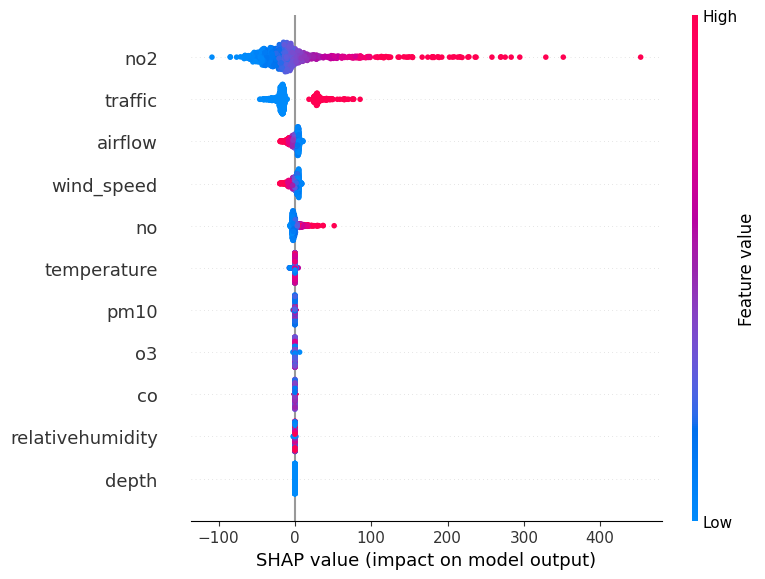

In [ ]:
import shap

explainer = shap.Explainer(model_rf, X_train)

shap_values = explainer(X_test, check_additivity=False)

shap.summary_plot(shap_values, X_test)

#line graph visualization
🧠 What this graph proves:
Tunnel NOx should be higher than surface

Shows accumulation effect

Matches Phase 1 research (subway vs surface difference)

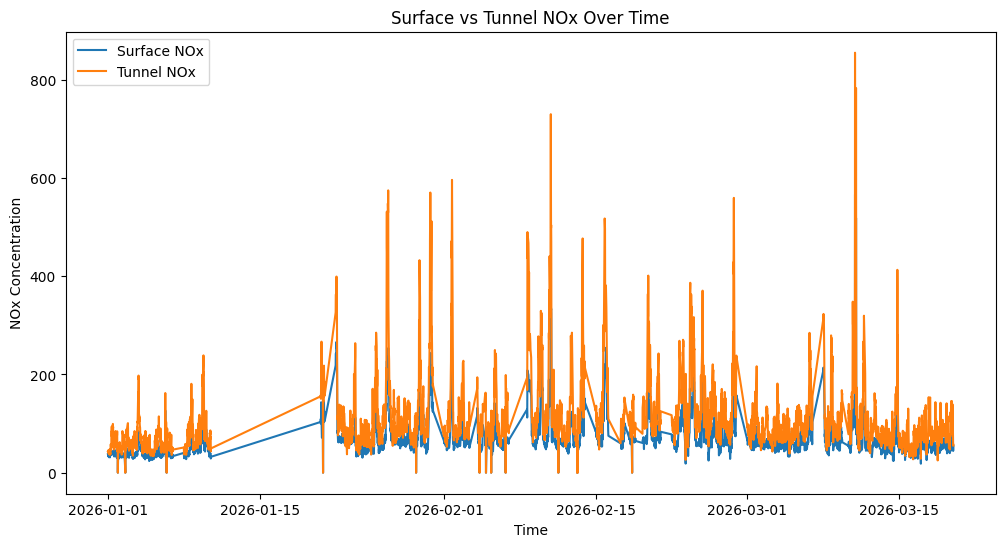

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(df['datetime'], df['nox'], label='Surface NOx')
plt.plot(df['datetime'], df['nox_tunnel'], label='Tunnel NOx')

plt.xlabel("Time")
plt.ylabel("NOx Concentration")
plt.title("Surface vs Tunnel NOx Over Time")

plt.legend()
plt.show()

#LIME

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=8fc18e54d65e41e76bac8a70ff56e835a4ef10a582edcbdd28b9fe95da28f2ab
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

In [ ]:
explainer = LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns,
    mode='regression'
)

In [ ]:
i = 10  # you can change index

exp = explainer.explain_instance(
    data_row=X_test.iloc[i],
    predict_fn=model_rf.predict
)

exp.show_in_notebook(show_table=True)

/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.12/dist-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

#ACTUAL VS PREDICTED

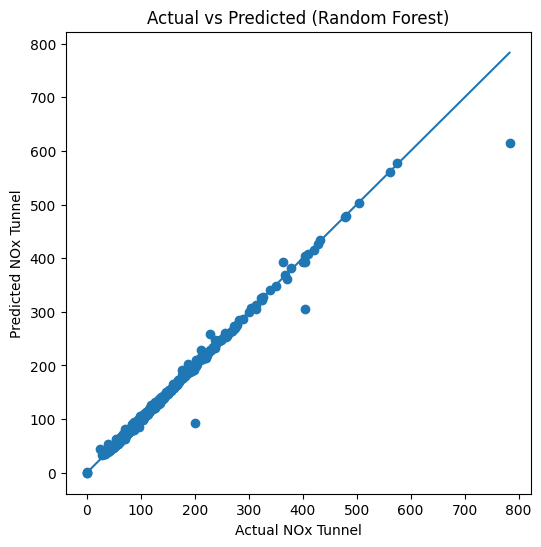

In [ ]:
y_pred_rf = model_rf.predict(X_test)

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_rf)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])

plt.xlabel("Actual NOx Tunnel")
plt.ylabel("Predicted NOx Tunnel")
plt.title("Actual vs Predicted (Random Forest)")

plt.show()

#RESIDUAL PLOT

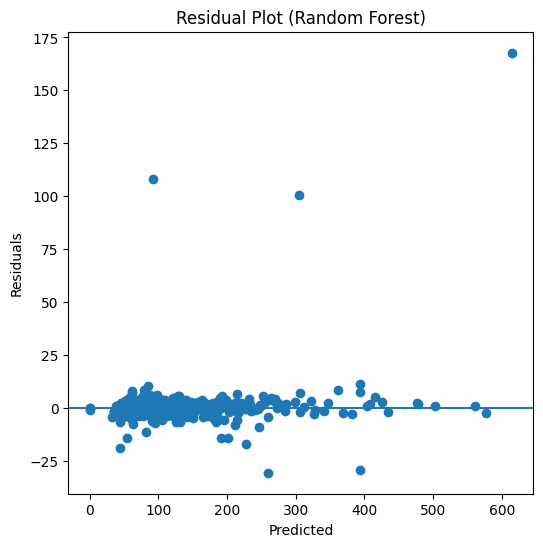

In [ ]:
residuals = y_test - y_pred_rf

plt.figure(figsize=(6,6))

plt.scatter(y_pred_rf, residuals)
plt.axhline(y=0)

plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot (Random Forest)")

plt.show()

#CORRELATION GRAPH

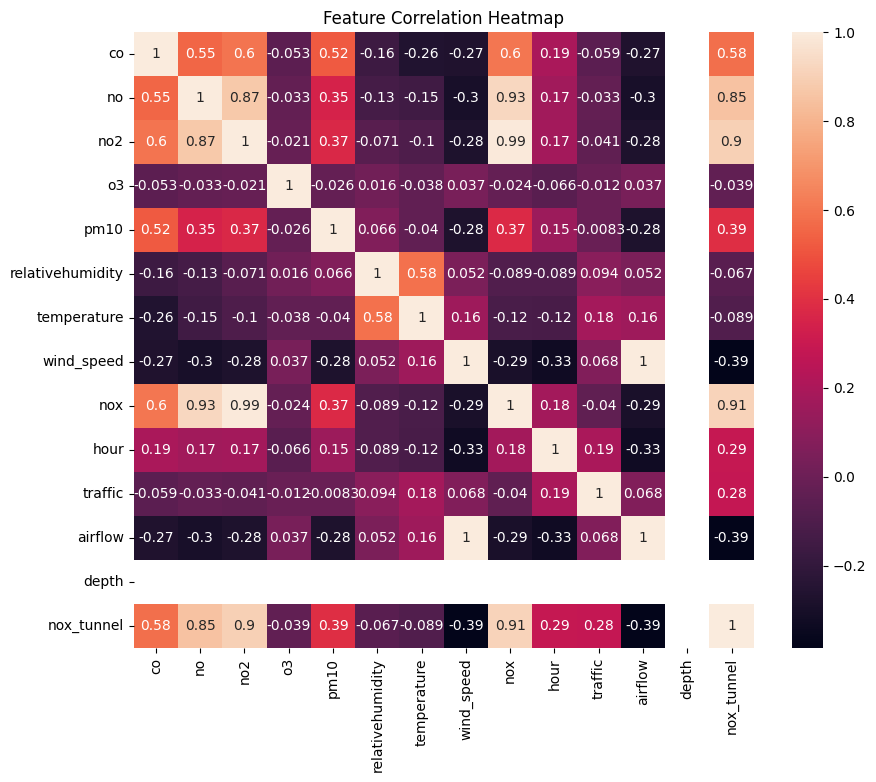

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.title("Feature Correlation Heatmap")
plt.show()

#FINAL PREDICTION FUNCTION

In [ ]:
def predict_nox_tunnel(input_dict):
    import pandas as pd

    input_df = pd.DataFrame([input_dict])

    prediction = model_rf.predict(input_df)[0]

    return prediction

In [ ]:
sample_input = {
    "co": 1.2,
    "no": 7.0,
    "no2": 30.0,
    "o3": 25.0,
    "pm10": 250,
    "relativehumidity": 15,
    "temperature": 11,
    "wind_speed": 0.8,
    "traffic": 0.5,
    "airflow": 0.2,
    "depth": 20
}

print("Predicted NOx Tunnel:", predict_nox_tunnel(sample_input))

Predicted NOx Tunnel: 44.57102223571818


#SAVE MODEL

In [ ]:
import joblib

joblib.dump(model_rf, "RESEARCH_model.pkl")

['RESEARCH_model.pkl']

In [ ]:
#LOAD
model_rf = joblib.load("RESEARCH_model.pkl")

In [ ]:
co = float(input("Enter CO: "))
no = float(input("Enter NO: "))
no2 = float(input("Enter NO2: "))
o3 = float(input("Enter O3: "))
pm10 = float(input("Enter PM10: "))
rh = float(input("Enter Humidity: "))
temp = float(input("Enter Temperature: "))
wind = float(input("Enter Wind Speed: "))
traffic = float(input("Enter Traffic (0–1): "))
airflow = float(input("Enter Airflow: "))
depth = float(input("Enter Depth: "))

import pandas as pd

data = pd.DataFrame([{
    "co": co,
    "no": no,
    "no2": no2,
    "o3": o3,
    "pm10": pm10,
    "relativehumidity": rh,
    "temperature": temp,
    "wind_speed": wind,
    "traffic": traffic,
    "airflow": airflow,
    "depth": depth
}])

prediction = model_rf.predict(data)

print("🚇 Predicted Tunnel NOx:", prediction[0])

Enter CO: 1.189
Enter NO: 7.32
Enter NO2: 30.38
Enter O3: 39
Enter PM10: 275.3
Enter Humidity: 15.12
Enter Temperature: 10
Enter Wind Speed: 0.82
Enter Traffic (0–1): 1
Enter Airflow: 2
Enter Depth: 4
🚇 Predicted Tunnel NOx: 40.05386317780253


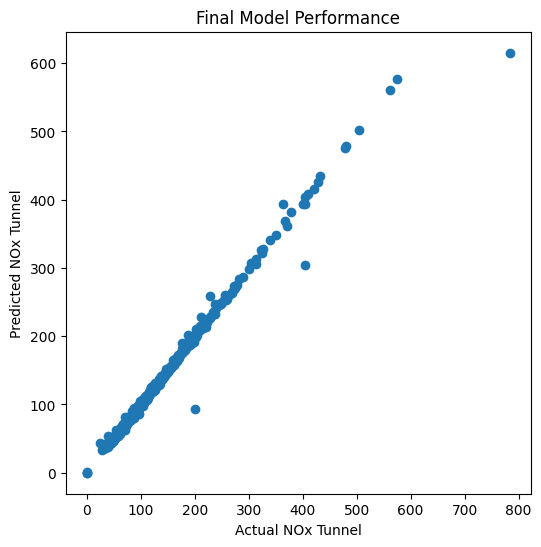

In [ ]:
import matplotlib.pyplot as plt

y_pred = model_rf.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual NOx Tunnel")
plt.ylabel("Predicted NOx Tunnel")
plt.title("Final Model Performance")
plt.show()

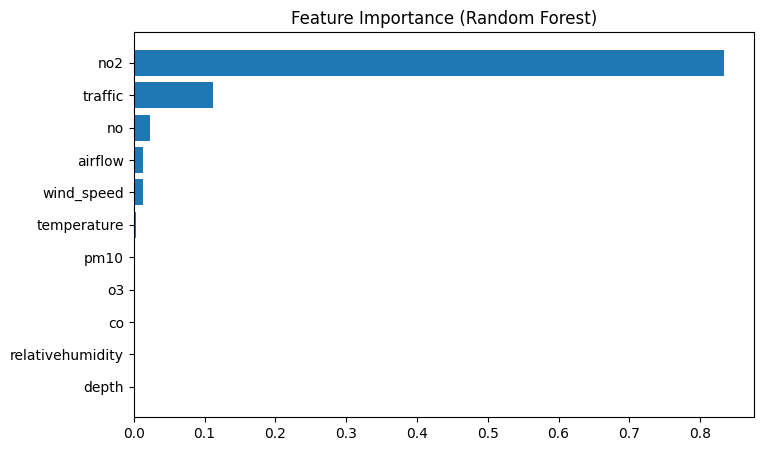

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance = model_rf.feature_importances_
features = X.columns

df_imp = pd.DataFrame({
    "feature": features,
    "importance": importance
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(8,5))
plt.barh(df_imp["feature"], df_imp["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance (Random Forest)")
plt.show()

#final dashboard building

In [ ]:
#LOAD
model_rf = joblib.load("RESEARCH_model.pkl")

In [ ]:
!pip install flask flask-ngrok joblib

In [ ]:
from google.colab import files
uploaded = files.upload()

KeyboardInterrupt: 

In [ ]:
import joblib

model = joblib.load("RESEARCH_model.pkl")
print("Model loaded successfully ✅")

Model loaded successfully ✅


In [ ]:
from flask import Flask, request, jsonify
from flask_ngrok import run_with_ngrok
import numpy as np
import joblib

app = Flask(__name__)
run_with_ngrok(app)  # 🔥 makes it public

# Load model
model = joblib.load("RESEARCH_model.pkl")

@app.route("/")
def home():
    return "NOx Prediction Server Running 🚀"

@app.route("/predict", methods=["POST"])
def predict():
    data = request.json

    features = [
        data["co"],
        data["no"],
        data["no2"],
        data["o3"],
        data["pm10"],
        data["relativehumidity"],
        data["temperature"],
        data["wind_speed"],
        data["traffic"],
        data["airflow"],
        data["depth"]
    ]

    features = np.array(features).reshape(1, -1)

    prediction = model.predict(features)[0]

    return jsonify({"predicted_nox": float(prediction)})

app.run()

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
Exception in thread Thread-6:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/urllib3/connection.py", line 198, in _new_conn
    sock = connection.create_connection(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/urllib3/util/connection.py", line 85, in create_connection
    raise err
  File "/usr/local/lib/python3.12/dist-packages/urllib3/util/connection.py", line 73, in create_connection
    sock.connect(sa)
ConnectionRefusedError: [Errno 111] Connection refused

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py", line 787, in urlopen
    response = self._make_request(
            